In [3]:
import numpy as np
from math import sqrt
from pprint import pprint

from sklearn import datasets, linear_model, metrics
from sklearn.neighbors import KNeighborsRegressor        # regresión con K vecinos más cercanos
from sklearn.preprocessing import StandardScaler         # estandarización de features
from sklearn.feature_selection import SelectPercentile, f_regression  # selección de características
from sklearn.metrics import make_scorer
from sklearn.model_selection import (
    cross_val_predict,   # predicciones por validación cruzada
    cross_val_score,     # puntuación por validación cruzada
    cross_validate,      # validación cruzada con múltiples métricas
    train_test_split,    # partición hold-out
    KFold                # partición en K subconjuntos
)
from sklearn import preprocessing

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # suprimir warnings de sklearn

In [4]:
# CARGA DEL DATASET CALIFORNIA HOUSING

dataset = datasets.fetch_california_housing()

X = dataset.data    # matriz de features (8 variables socioeconómicas por distrito)
y = dataset.target  # precio medio de vivienda en cientos de miles de dólares

print(np.shape(X))  # → (20640, 8) → 20640 muestras, 8 features

(20640, 8)


In [5]:
# DEFINICIÓN DE MÉTRICAS DE EVALUACIÓN

metricas = {
    # MAE (Mean Absolute Error): error absoluto medio
    # ya está integrada en sklearn, se referencia por nombre
    'MAE': 'neg_mean_absolute_error',

    # RMSE (Root Mean Squared Error): raíz del error cuadrático medio
    # no está directamente en sklearn → se calcula con lambda
    # greater_is_better=False → indica que menor valor = mejor modelo
    'RMSE': make_scorer(lambda y, y_pred:
                sqrt(metrics.mean_squared_error(y, y_pred)),
                greater_is_better=False),

    # MAPE (Mean Absolute Percentage Error): error porcentual absoluto medio
    # mide el error en % respecto al valor real → más interpretable
    # greater_is_better=False → menor % = mejor modelo
    'MAPE': make_scorer(lambda y, y_pred:
                np.mean(np.abs((y - y_pred) / y)) * 100,
                greater_is_better=False)
}

### 1) PARTICIÓN EXTERNA DE DATOS

In [9]:
# 1) PARTICIÓN HOLD-OUT

# Divide el dataset en train (80%) y test (20%)
# random_state=42 → resultados reproducibles
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)

print(np.shape(X_training))  # → (16512, 8) → 80% de las muestras, 8 features
print(np.shape(X_testing))   # → (4128, 8)  → 20% de las muestras, 8 features

(16512, 8)
(4128, 8)


### 2-5) ENTRENAMIENTO

In [ ]:
# 2) Extracción de características
# 3) Selección de atributos

In [10]:
# 4) ESTANDARIZACIÓN DE LOS DATOS DE ENTRENAMIENTO

standardizer = preprocessing.StandardScaler()

# fit_transform() = fit() + transform() en una sola línea
# Aprende la media y std de X_training y aplica la estandarización al mismo tiempo
# Equivalente al código anterior:
#   stdr_trained = standardizer.fit(X_training)
#   X_stdr = stdr_trained.transform(X_training)
X_stdr = standardizer.fit_transform(X_training)

fit_transform solo se usa con training. Para el test debes usar solo transform

In [6]:
# 5) CONSTRUCCIÓN DEL MODELO KNN PARA REGRESIÓN

k = 10  # número de vecinos a considerar

reg = KNeighborsRegressor(
    n_neighbors = k,          # usa los 10 vecinos más cercanos para predecir
    weights     = 'distance', # vecinos más cercanos tienen más peso en la predicción
    metric      = 'euclidean' # distancia euclídea para medir similitud entre puntos
)

In [11]:
# 5.1) VALIDACIÓN CRUZADA INTERNA

# cross_val_score evalúa el modelo con validación cruzada
# Parámetros:
#   reg          → modelo KNN definido en el paso anterior
#   X_stdr       → datos de entrenamiento estandarizados
#   y_training   → etiquetas de entrenamiento
#   cv           → KFold con 5 particiones, aleatorias y semilla 42
#   scoring      → métrica R² (coeficiente de determinación, 1=perfecto, 0=malo)
r2_cv_results = cross_val_score(reg, X_stdr, y_training,
                                cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='r2')

print("cross_val_R2:   %0.4f +/- %0.4f" % (r2_cv_results.mean(), r2_cv_results.std()))

cross_val_R2:   0.6962 +/- 0.0096


In [12]:
# VALIDACIÓN CRUZADA CON MÚLTIPLES MÉTRICAS

# cross_validate permite evaluar varias métricas a la vez (a diferencia de cross_val_score)
# Parámetros:
#   reg        → modelo KNN definido anteriormente
#   X_stdr     → datos estandarizados
#   y_training → etiquetas de entrenamiento
#   cv         → KFold 5 bolsas, aleatorio, semilla 42
#   scoring    → diccionario de métricas definido anteriormente (MAE, RMSE, MAPE)
metrics_cv_results = cross_validate(reg, X_stdr, y_training,
                                    cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                    scoring=metricas)

pprint(metrics_cv_results)

{'fit_time': array([0.06648111, 0.09778261, 0.08291006, 0.02336144, 0.05097222]),
 'score_time': array([1.2464869 , 1.40834379, 1.08845782, 0.51788783, 0.59875679]),
 'test_MAE': array([-0.45508636, -0.43747382, -0.42656226, -0.43984405, -0.43381931]),
 'test_MAPE': array([-24.61909207, -23.96339877, -23.97232907, -24.28066021,
       -23.49003617]),
 'test_RMSE': array([-0.65342222, -0.63534593, -0.61742286, -0.65008873, -0.62943728])}


In [13]:
# EXTRAER PREDICCIONES DE LA VALIDACIÓN CRUZADA

# cross_val_predict devuelve la predicción de cada muestra
# cuando era parte del conjunto de validación (test) en su bolsa
y_pred = cross_val_predict(reg, X_stdr, y_training,
                           cv=KFold(n_splits=5, shuffle=True, random_state=42))

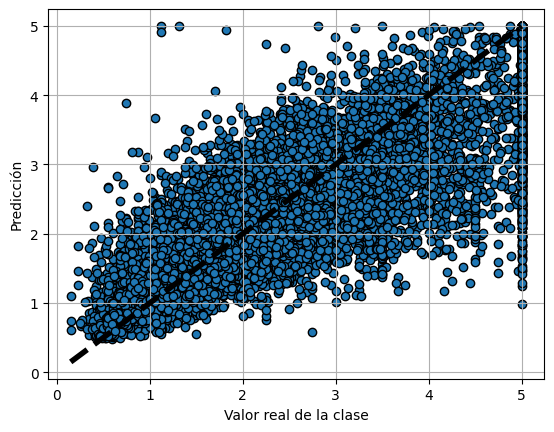

In [14]:
# Función que visualiza predicciones vs valores reales
# Si el modelo es perfecto, todos los puntos caerían sobre la bisectriz (línea diagonal)
def plot_bisectriz(y, y_pred):
    fig, ax = plt.subplots()
    ax.scatter(y, y_pred, edgecolors=(0, 0, 0))  # puntos: real vs predicho
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)  # línea bisectriz
    ax.set_xlabel('Valor real de la clase')
    ax.set_ylabel('Predicción')
    plt.grid()
    plt.show()

# Llamar a la función con los valores reales y las predicciones del CV
plot_bisectriz(y_training, y_pred)

In [15]:
# 5.2) Entrenamiento del modelo definitivo
model = reg.fit(X_stdr, y_training)

### 6-10) PREDICCIÓN

In [ ]:
# 6) Extracción de las características de test
# 7) Selección de los atributos de test

In [21]:
# 8) Estandarización de las característiacs de test
X_test_stdr = standardizer.transform(X_testing)

In [22]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)

MAE:  0.4368
MSE: 0.4163
RMSE: 0.6452
R2:   0.6823


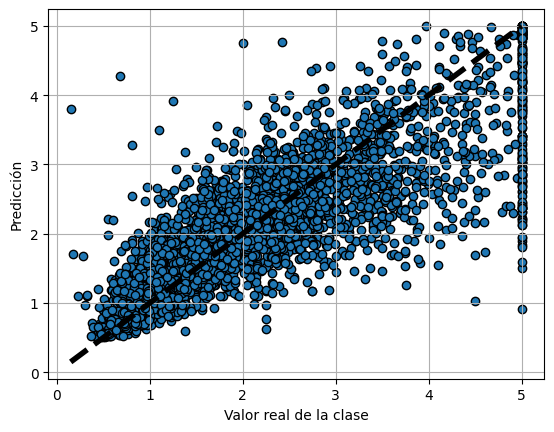

In [30]:
# 10) Evaluación del modelo sobre el conjunto de test
MAE = metrics.mean_absolute_error(y_testing, y_pred_test)
MSE = metrics.mean_squared_error(y_testing, y_pred_test)
RMSE = metrics.root_mean_squared_error(y_testing, y_pred_test)
R2 = metrics.r2_score(y_testing, y_pred_test)

print('MAE:  %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('R2:   %.4f' % R2)

# Visualización de resultados
plot_bisectriz(y_testing, y_pred_test)

### ACTIVIDAD EXTRA

#### Entrenar el mejor modelo posible con el algoritmo KNN y comparar el resultado con el modelo OLS en test

Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
Mejor R2 en CV:     0.7284

Métrica           KNN        OLS
--------------------------------
KNN        MAE=0.4067  RMSE=0.6050  R2=0.7207
OLS        MAE=0.5332  RMSE=0.7456  R2=0.5758


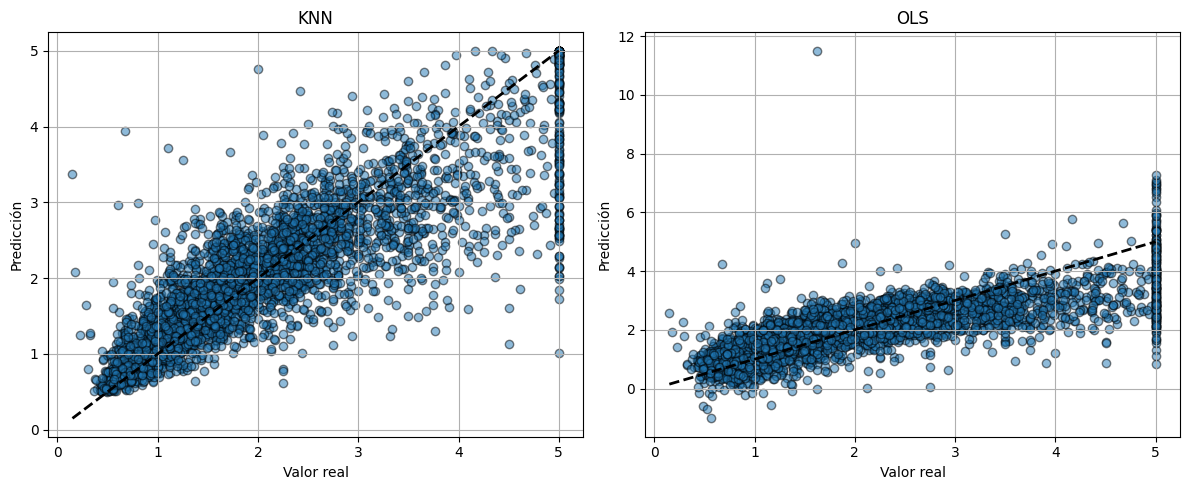

In [31]:
from sklearn.model_selection import GridSearchCV

# Definir parámetros de búsqueda
# GridSearchCV probará todas las combinaciones posibles
param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],           # distintos valores de K
    'weights':     ['uniform', 'distance'],           # ponderación de vecinos
    'metric':      ['euclidean', 'manhattan']         # métrica de distancia
}

# Aplicar el algoritmo de búsqueda con validación cruzada de 5 bolsas
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid,
                           cv=KFold(n_splits=5, shuffle=True, random_state=42),
                           scoring='r2')

# Entrenar el modelo (busca la mejor combinación de parámetros)
grid_search.fit(X_stdr, y_training)

# Extraer los mejores parámetros encontrados
print('Mejores parámetros:', grid_search.best_params_)
print('Mejor R2 en CV:    ', round(grid_search.best_score_, 4))

# ---- COMPARACIÓN KNN vs OLS sobre test ----

# Estandarizar test
X_testing_stdr = standardizer.transform(X_testing)

# Mejor KNN
best_knn = grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_testing_stdr)

# OLS (Ordinary Least Squares = regresión lineal)
ols = linear_model.LinearRegression()
ols.fit(X_stdr, y_training)
y_pred_ols = ols.predict(X_testing_stdr)

# Comparación cuantitativa
print('\n{:<10} {:>10} {:>10}'.format('Métrica', 'KNN', 'OLS'))
print('-' * 32)
for nombre, yp in [('KNN', y_pred_knn), ('OLS', y_pred_ols)]:
    mae  = metrics.mean_absolute_error(y_testing, yp)
    rmse = sqrt(metrics.mean_squared_error(y_testing, yp))
    r2   = metrics.r2_score(y_testing, yp)
    print(f'{nombre:<10} MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

# Comparación cualitativa (bisectriz)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, (nombre, yp) in enumerate([('KNN', y_pred_knn), ('OLS', y_pred_ols)]):
    ax[i].scatter(y_testing, yp, edgecolors=(0,0,0), alpha=0.5)
    ax[i].plot([y_testing.min(), y_testing.max()],
               [y_testing.min(), y_testing.max()], 'k--', lw=2)
    ax[i].set_title(nombre)
    ax[i].set_xlabel('Valor real')
    ax[i].set_ylabel('Predicción')
    ax[i].grid()
plt.tight_layout()
plt.show()